# Image Analysis 2

A cleaner version of the image analysis workflow for tweezer-array frames.

This notebook keeps the same basic steps as the original analysis: load the TIFF stack, clean up the image shape if needed, apply a high-pass filter, detect trap sites, and plot the result.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os 

sys.path.append(os.path.abspath('..'))



from pytweezer.analysis import analysis as pyt
import tifffile as tiff 


In [ ]:
cpp_dir = os.path.abspath(os.path.join('..', 'cpp_implementations'))
if cpp_dir not in sys.path:
    sys.path.insert(0, cpp_dir)

from cpp_implementations.filter import batch_white_tophat as cpp
# from cpp_implementations.detection import detect_trap_sites_py 


folder_path = r"100ms expo"
image_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.tiff')])
images = [tiff.imread(os.path.join(folder_path, f)) for f in image_files]
raw_stack = np.array(images)

raw_stack = np.array(images)
# Keep only the first color channel to make it (N, H, W)
raw_stack = raw_stack[:, :, :, 0]


feature_size = 10


python_tophat_stack = np.stack([
    pyt.morphological_tophat_high_pass(image, feature_size=feature_size)
    for image in raw_stack
])
cpp_filtered_stack = cpp.batch_white_tophat(raw_stack.astype(np.float32), feature_size)
filtered_mean_python = python_tophat_stack.mean(axis=0)
filtered_mean_cpp = cpp_filtered_stack.mean(axis=0)

print(f'C++ filtered stack shape: {cpp_filtered_stack.shape}')
print(f'Max abs diff vs Python tophat: {np.max(np.abs(cpp_filtered_stack - python_tophat_stack)):.6f}')
print(f'C++ filtered mean range: {filtered_mean_cpp.min():.4f} to {filtered_mean_cpp.max():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(filtered_mean_python, cmap='magma')
axes[0].set_title('Python morphological_tophat_high_pass mean')
axes[0].axis('off')

axes[1].imshow(filtered_mean_cpp, cmap='magma')
axes[1].set_title('C++ batch_white_tophat mean')
axes[1].axis('off')
plt.tight_layout()
plt.show()

ImportError: cannot import name 'detect_trap_sites_py' from 'cpp_implementations.detection' (unknown location)

In [7]:
grid_shape=[16, 16]


grid_positions_cpp, detection_threshold_cpp = cpp.detect_trap_sites(
    filtered_mean_cpp,
    grid_shape[0],
    grid_shape[1],
    10.0,
)

grid_positions_python, detection_threshold_python = pyt.detect_trap_sites(
    filtered_mean_cpp,
    grid_shape,
    10.0,
)

python_centers = np.array([
    grid_positions_python[(row, col)]
    for row in range(grid_shape[0])
    for col in range(grid_shape[1])
])
cpp_centers = np.asarray(grid_positions_cpp)

print(f'Python detection threshold: {detection_threshold_python:.4f}')
print(f'C++ detection threshold:    {detection_threshold_cpp:.4f}')
print(f'Max abs center diff:        {np.max(np.abs(python_centers - cpp_centers)):.0f} px')

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(filtered_mean_cpp, cmap='magma')
ax.scatter(python_centers[:, 1], python_centers[:, 0], facecolors='none', edgecolors='cyan', marker='s', s=60, linewidths=1.0, label='Python')
ax.scatter(cpp_centers[:, 1], cpp_centers[:, 0], facecolors='none', edgecolors='yellow', marker='o', s=26, linewidths=1.0, label='C++')
ax.set_title('Trap-site detection on C++ white-tophat mean')
ax.legend()
plt.show()

AttributeError: module 'cpp_implementations.filter' has no attribute 'detect_trap_sites'

---- 03/06Jun/202026 Tweezer Experiment Analysis Initialised ----
Trap (0, 0) Loading Probability : 57.00 %
Trap (0, 1) Loading Probability : 50.50 %
Trap (0, 2) Loading Probability : 52.50 %
Trap (0, 3) Loading Probability : 53.00 %
Trap (0, 4) Loading Probability : 57.00 %
Trap (0, 5) Loading Probability : 53.50 %
Trap (0, 6) Loading Probability : 47.50 %
Trap (0, 7) Loading Probability : 48.00 %
Trap (0, 8) Loading Probability : 50.00 %
Trap (0, 9) Loading Probability : 46.00 %
Trap (0, 10) Loading Probability : 51.50 %
Trap (0, 11) Loading Probability : 55.00 %
Trap (0, 12) Loading Probability : 48.00 %
Trap (0, 13) Loading Probability : 56.00 %
Trap (0, 14) Loading Probability : 49.50 %
Trap (0, 15) Loading Probability : 52.50 %
Trap (1, 0) Loading Probability : 56.00 %
Trap (1, 1) Loading Probability : 58.50 %
Trap (1, 2) Loading Probability : 64.00 %
Trap (1, 3) Loading Probability : 54.50 %
Trap (1, 4) Loading Probability : 54.00 %
Trap (1, 5) Loading Probability : 52.50 %
Trap

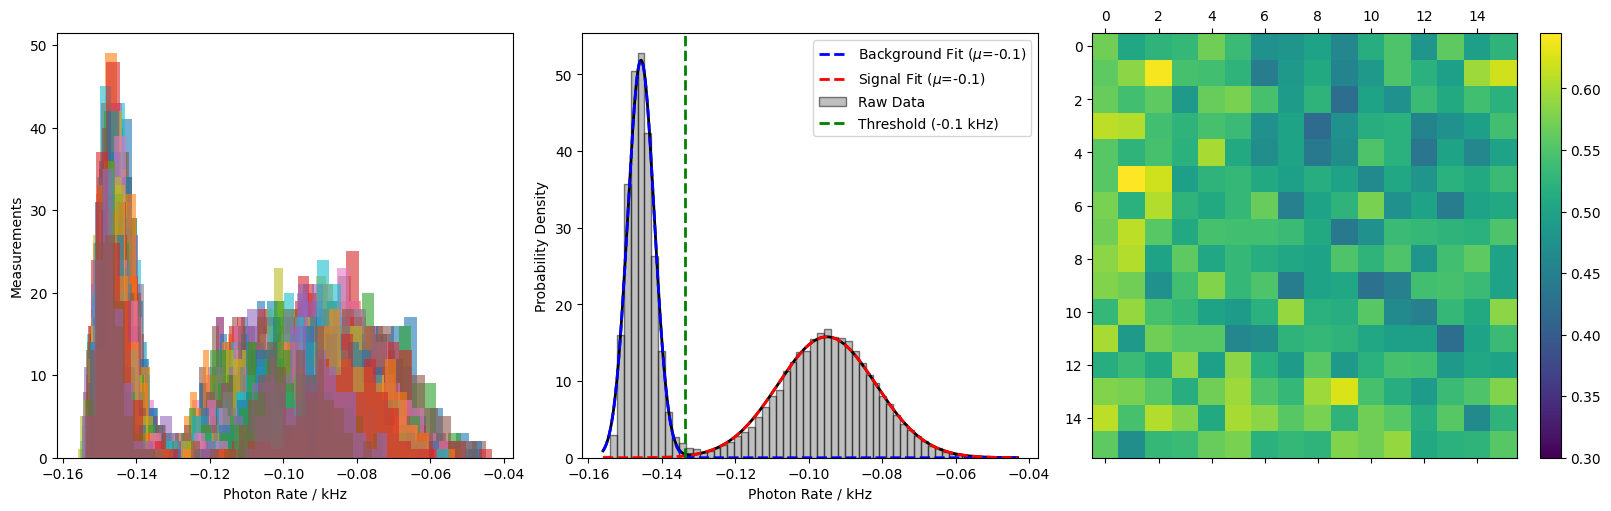

In [9]:
imgs_filtered_cpp = list(cpp_filtered_stack)
grid_positions_cpp_dict = {
    (row, col): tuple(cpp_centers[row * grid_shape[1] + col])
    for row in range(grid_shape[0])
    for col in range(grid_shape[1])
}

window_size = 3

texp = pyt.TweezerExperimentAnalysis(day='03', month='06Jun', year='2026')


photon_rates_cpp, loading_probabilities_cpp, loading_threshold_cpp, loading_fidelity_cpp = texp.get_array_loading_statistics(
    imgs_filtered_cpp,
    grid_positions_cpp_dict,
    grid_shape,
    threshold_detection=True,
    window_size=window_size,
    binning=60,
)

print(f'Loading threshold (C++ path): {loading_threshold_cpp:.4f}')
print(f'Loading fidelity (C++ path):  {loading_fidelity_cpp:.4%}')
print(f'Photon rates shape:           {np.shape(photon_rates_cpp)}')

In [10]:
import time

# Time Python morphological tophat
t_start_python = time.perf_counter()
python_stack = np.stack([
    pyt.morphological_tophat_high_pass(image, feature_size=feature_size)
    for image in raw_stack
])
t_end_python = time.perf_counter()
t_python = t_end_python - t_start_python

# Time C++ batch white tophat
t_start_cpp = time.perf_counter()
cpp_stack = cpp.batch_white_tophat(raw_stack.astype(np.float32), feature_size)
t_end_cpp = time.perf_counter()
t_cpp = t_end_cpp - t_start_cpp

# Report results
speedup = t_python / t_cpp
print(f'Python morphological_tophat_high_pass: {t_python*1e3:.2f} ms ({t_python/len(raw_stack)*1e3:.4f} ms/frame)')
print(f'C++ batch_white_tophat:                {t_cpp*1e3:.2f} ms ({t_cpp/len(raw_stack)*1e3:.4f} ms/frame)')
print(f'Speedup: {speedup:.1f}x')

Python morphological_tophat_high_pass: 327.59 ms (1.6380 ms/frame)
C++ batch_white_tophat:                170.09 ms (0.8505 ms/frame)
Speedup: 1.9x


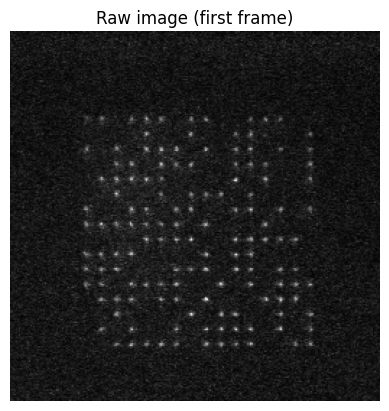

C++ white_tophat time: 0.001044 seconds


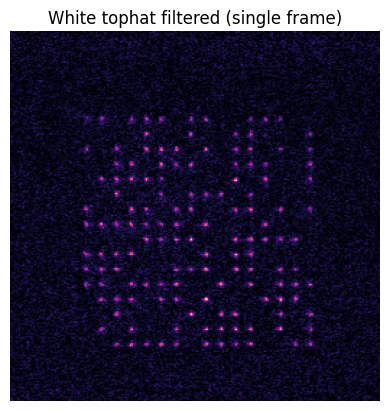

In [2]:
import os
import sys
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt

import time 

cpp_dir = os.path.abspath(os.path.join('..'))
if cpp_dir not in sys.path:
    sys.path.insert(0, cpp_dir)


image = tiff.imread('100ms expo/img_0.tiff')[:, :, 0]  # single (H, W) frame

plt.imshow(image, cmap='gray')
plt.title('Raw image (first frame)')
plt.axis('off')
plt.show()


from cpp_implementations.filter import white_tophat
time_1 = time.perf_counter()
filtered = white_tophat(image, 10)        # one (H, W) frame
finish_time = time.perf_counter()
print(f'C++ white_tophat time: {finish_time - time_1:.6f} seconds')

plt.imshow(filtered, cmap='magma')
plt.title('White tophat filtered (single frame)')
plt.axis('off')
plt.show()


# filtered = batch_white_tophat(stack, 10)  # whole (n, H, W) stack, one call